## Pandas - explode()

In [2]:
# Importing Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Developer\python_course_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
help(df.explode)

Help on method explode in module pandas.core.frame:

explode(column: 'IndexLabel', ignore_index: 'bool' = False) -> 'DataFrame' method of pandas.DataFrame instance
    Transform each element of a list-like to a row, replicating index values.
    
    Parameters
    ----------
    column : IndexLabel
        Column(s) to explode.
        For multiple columns, specify a non-empty list with each element
        be str or tuple, and all specified columns their list-like data
        on same row of the frame must have matching length.
    
    ignore_index : bool, default False
        If True, the resulting index will be labeled 0, 1, …, n - 1.
    
    Returns
    -------
    DataFrame
        Exploded lists to rows of the subset columns;
        index will be duplicated for these rows.
    
    Raises
    ------
    ValueError :
        * If columns of the frame are not unique.
        * If specified columns to explode is empty list.
        * If specified columns to explode have not mat

In [4]:
skills = df['job_skills'].explode(ignore_index=True)

In [5]:
print(len(df))
print(df['job_skills'].memory_usage(deep=True) / 1024**2, "MB")

785741
91.04693984985352 MB


In [13]:
df_exploded = df.explode('job_skills')

<Axes: xlabel='job_skills'>

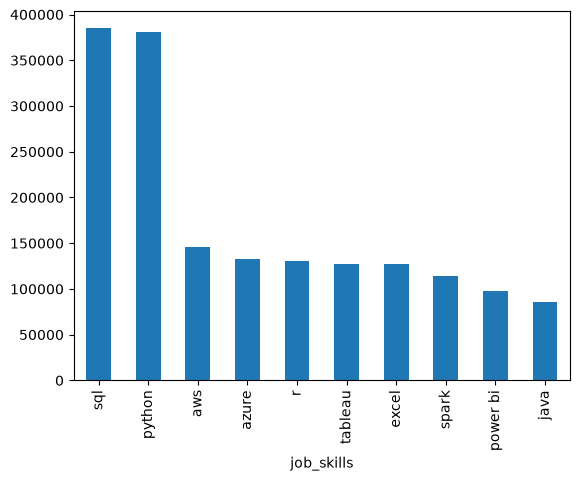

In [14]:
df_exploded['job_skills'].value_counts().head(10).plot(kind = 'bar')

In [18]:
skills_count = df_exploded.groupby(['job_title_short', 'job_skills']).size()

type(skills_count)

skills_count

job_title_short    job_skills
Business Analyst   airflow        318
                   airtable        17
                   alteryx       1078
                   angular         87
                   ansible        120
                                 ... 
Software Engineer  wrike            4
                   wsl             13
                   xamarin         35
                   yarn           145
                   zoom           229
Length: 2256, dtype: int64

In [19]:
# Convert skills_count to a dataframe instead of keeping it as a series

df_skills_count = skills_count.reset_index(name = 'skill_count')
df_skills_count

,job_title_short,job_skills,skill_count
0,Business Analyst,airflow,318
1,Business Analyst,airtable,17
2,Business Analyst,alteryx,1078
3,Business Analyst,angular,87
4,Business Analyst,ansible,120
...,...,...,...
2251,Software Engineer,wrike,4
2252,Software Engineer,wsl,13
2253,Software Engineer,xamarin,35
2254,Software Engineer,yarn,145


In [21]:
# Sorting the values in df_skills_count as per the skill_count column

df_skills_count = df_skills_count.sort_values(by = 'skill_count', ascending = False)
df_skills_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
462,Data Analyst,chainer,1
432,Cloud Engineer,wrike,1
410,Cloud Engineer,theano,1
24,Business Analyst,chainer,1


    job_title_short  job_skills  skill_count
625    Data Analyst         sql        92428
494    Data Analyst       excel        66860
590    Data Analyst      python        57190
638    Data Analyst     tableau        46455
583    Data Analyst    power bi        39380
594    Data Analyst           r        29996
606    Data Analyst         sas        27998
585    Data Analyst  powerpoint        13822
664    Data Analyst        word        13562
605    Data Analyst         sap        11280


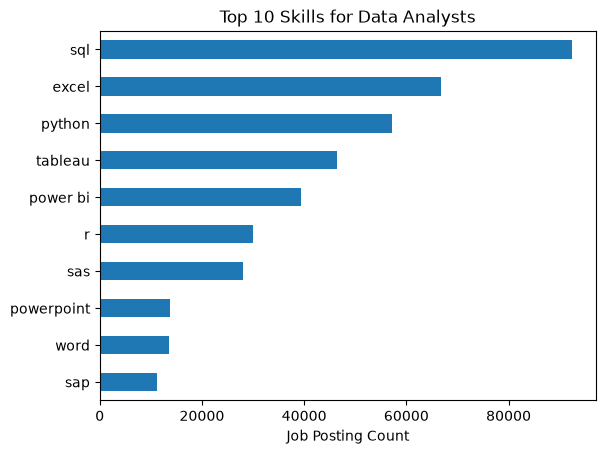

In [32]:
# To print the top 10 skills for the 'Data Analyst' role
# Can be performed for all the job titles

job_title = 'Data Analyst'
top_skill = 10

df_skills_final = df_skills_count[df_skills_count['job_title_short'] == job_title].head(top_skill)
print(df_skills_final)

df_skills_final.plot(kind = 'barh', x = 'job_skills', y = 'skill_count')

# gca refers to 'get current axis' and invert_yaxis() is used to presen the barh in descending order bars
plt.gca().invert_yaxis()
plt.title(f'Top {top_skill} Skills for {job_title}s')
plt.xlabel('Job Posting Count')
plt.ylabel('')
plt.legend().set_visible(False)
plt.show()

In [25]:
df_skills_final['job_skills'].head(10)

625           sql
494         excel
590        python
638       tableau
583      power bi
594             r
606           sas
585    powerpoint
664          word
605           sap
Name: job_skills, dtype: str